In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
import csv
import os

DATA_ROOT = '../data/raw'
RESULTS_LOG = '../results/results_log.csv'

LANGS = {
    'eng': 'English',
    'afr': 'Afrikaans',
    'hau': 'Hausa',
    'kin': 'Kinyarwanda'
}

print("Loading multilingual sentence-transformers model...")
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
print("Model loaded.")

Loading multilingual sentence-transformers model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded.


In [2]:
def run_baseline(lang_code, split='test'):
    path = f'{DATA_ROOT}/{lang_code}/{split}.csv'
    if not os.path.exists(path):
        print(f"  Skipping {lang_code} {split} — file not found.")
        return None, None

    df = pd.read_csv(path)
    print(f"\nRunning baseline on {LANGS[lang_code]} ({split}, n={len(df)})...")

    emb1 = model.encode(df['sentence1'].tolist(), show_progress_bar=True, batch_size=64)
    emb2 = model.encode(df['sentence2'].tolist(), show_progress_bar=True, batch_size=64)

    # Cosine similarity
    norms1 = np.linalg.norm(emb1, axis=1, keepdims=True)
    norms2 = np.linalg.norm(emb2, axis=1, keepdims=True)
    sims = np.sum((emb1 / norms1) * (emb2 / norms2), axis=1)

    rho, _ = spearmanr(sims, df['label'])
    mse = mean_squared_error(df['label'], sims)

    print(f"  Spearman ρ = {rho:.4f} | MSE = {mse:.4f}")
    return rho, mse

In [3]:
results = []

for lang_code in ['eng', 'afr', 'hau', 'kin']:
    rho, mse = run_baseline(lang_code, split='test')
    if rho is not None:
        results.append({
            'experiment_id': f'BL-1-{lang_code}',
            'model': 'cosine_baseline',
            'model_variant': 'paraphrase-multilingual-mpnet-base-v2',
            'language': LANGS[lang_code],
            'split': 'test',
            'spearman_rho': round(rho, 4),
            'mse': round(mse, 4),
            'augmented': False,
            'notes': 'No fine-tuning. Cosine similarity on sentence embeddings.'
        })

# Append to results log
with open(RESULTS_LOG, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'experiment_id','model','model_variant','language',
        'split','spearman_rho','mse','augmented','notes'
    ])
    for row in results:
        writer.writerow(row)

print("\n✓ Results logged to results_log.csv")
print("\nSummary:")
for r in results:
    print(f"  {r['language']:12s} | ρ = {r['spearman_rho']:.4f} | MSE = {r['mse']:.4f}")


Running baseline on English (test, n=2600)...


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

  Spearman ρ = 0.8048 | MSE = 0.0352

Running baseline on Afrikaans (test, n=375)...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

  Spearman ρ = 0.3175 | MSE = 0.1346

Running baseline on Kinyarwanda (test, n=222)...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  Spearman ρ = 0.3617 | MSE = 0.1426

✓ Results logged to results_log.csv

Summary:
  English      | ρ = 0.8048 | MSE = 0.0352
  Afrikaans    | ρ = 0.7646 | MSE = 0.0263
  Hausa        | ρ = 0.3175 | MSE = 0.1346
  Kinyarwanda  | ρ = 0.3617 | MSE = 0.1426


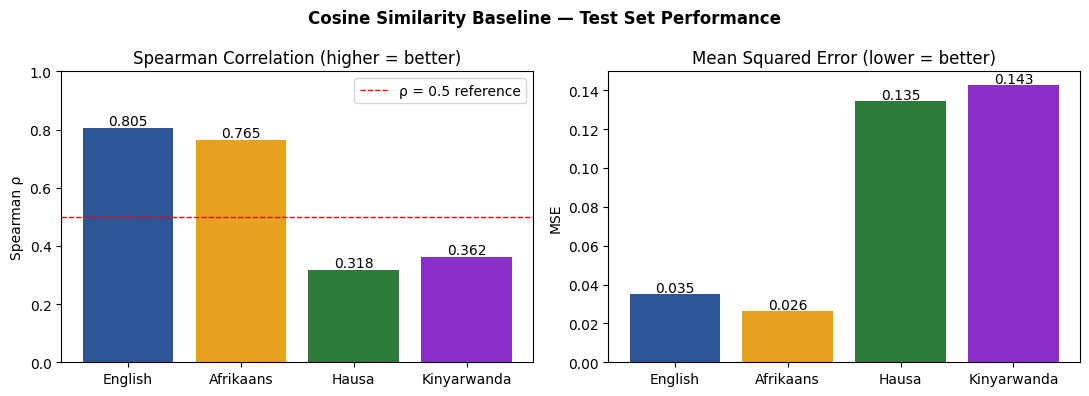

Saved → results/fig3_baseline_results.png


In [4]:
import matplotlib.pyplot as plt

langs_done = [r['language'] for r in results]
rhos = [r['spearman_rho'] for r in results]
mses = [r['mse'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Cosine Similarity Baseline — Test Set Performance', fontweight='bold')

axes[0].bar(langs_done, rhos, color=['#2E5596','#E8A020','#2D7A3A','#8B2FC9'])
axes[0].set_ylabel('Spearman ρ')
axes[0].set_ylim(0, 1)
axes[0].set_title('Spearman Correlation (higher = better)')
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='ρ = 0.5 reference')
axes[0].legend()
for i, v in enumerate(rhos):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(langs_done, mses, color=['#2E5596','#E8A020','#2D7A3A','#8B2FC9'])
axes[1].set_ylabel('MSE')
axes[1].set_title('Mean Squared Error (lower = better)')
for i, v in enumerate(mses):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/fig3_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/fig3_baseline_results.png")